# 📊 Ensemble Methods — Full Comparison

> **Part of:** Basics → Ensemble_Methods

---

## 🎯 Goal

Compare all 4 ensemble models on the **same dataset** (Breast Cancer):

| Model | Type | Notebook |
|---|---|---|
| Decision Tree | Baseline | — |
| Random Forest | Bagging | `Bagging/Random_Forest.ipynb` |
| XGBoost | Boosting | `Boosting/XGBoost.ipynb` |
| LightGBM | Boosting | `Boosting/LightGBM.ipynb` |

---

## 📐 Metrics Compared
- Accuracy
- Precision / Recall / F1-Score
- AUC-ROC
- Training Time
- Cross-Validation Score

---
## 📦 Step 1 — Import Libraries

In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported!')

✅ All libraries imported!


---
## 📊 Step 2 — Load Dataset

In [5]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Dataset        : Breast Cancer (sklearn)')
print('Shape          :', X.shape)
print('Classes        :', list(data.target_names))
print('Class Balance  :')
print(y.value_counts().to_string())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain : {X_train.shape[0]} | Test : {X_test.shape[0]}')

Dataset        : Breast Cancer (sklearn)
Shape          : (569, 30)
Classes        : [np.str_('malignant'), np.str_('benign')]
Class Balance  :
target
1    357
0    212

Train : 455 | Test : 114


---
## 🤖 Step 3 — Train All Models

In [6]:
models = {
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'       : XGBClassifier(n_estimators=100, learning_rate=0.1,
                                    eval_metric='logloss', random_state=42),
    'LightGBM'      : LGBMClassifier(n_estimators=100, learning_rate=0.1,
                                     num_leaves=31, random_state=42)
}

results = []

for name, model in models.items():
    # Training time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # Predictions
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Cross-val
    cv = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    results.append({
        'Model'       : name,
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'Precision'   : precision_score(y_test, y_pred),
        'Recall'      : recall_score(y_test, y_pred),
        'F1-Score'    : f1_score(y_test, y_pred),
        'AUC-ROC'     : roc_auc_score(y_test, y_proba),
        'CV Mean'     : cv.mean(),
        'CV Std'      : cv.std(),
        'Train Time'  : train_time
    })
    print(f'✅ {name} trained!')

df = pd.DataFrame(results).set_index('Model')
print('\n✅ All models trained successfully!')

✅ Decision Tree trained!
✅ Random Forest trained!
✅ XGBoost trained!
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

---
## 📋 Step 4 — Full Metrics Table

In [7]:
display_df = df[['Accuracy','Precision','Recall','F1-Score','AUC-ROC','CV Mean','CV Std','Train Time']].copy()

# Format for display
for col in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','CV Mean']:
    display_df[col] = display_df[col].map('{:.4f}'.format)
display_df['CV Std']     = display_df['CV Std'].map('±{:.4f}'.format)
display_df['Train Time'] = df['Train Time'].map('{:.4f}s'.format)

print('=' * 85)
print('                     ENSEMBLE METHODS — FULL COMPARISON')
print('=' * 85)
print(display_df.to_string())
print('=' * 85)

                     ENSEMBLE METHODS — FULL COMPARISON
              Accuracy Precision  Recall F1-Score AUC-ROC CV Mean   CV Std Train Time
Model                                                                                
Decision Tree   0.9123    0.9559  0.9028   0.9286  0.9157  0.9173  ±0.0242    0.1943s
Random Forest   0.9561    0.9589  0.9722   0.9655  0.9937  0.9561  ±0.0228    0.8923s
XGBoost         0.9474    0.9459  0.9722   0.9589  0.9924  0.9684  ±0.0180    1.0356s
LightGBM        0.9649    0.9595  0.9861   0.9726  0.9897  0.9701  ±0.0172   13.1199s


---
## 📊 Step 5 — Accuracy Comparison (Bar Chart)

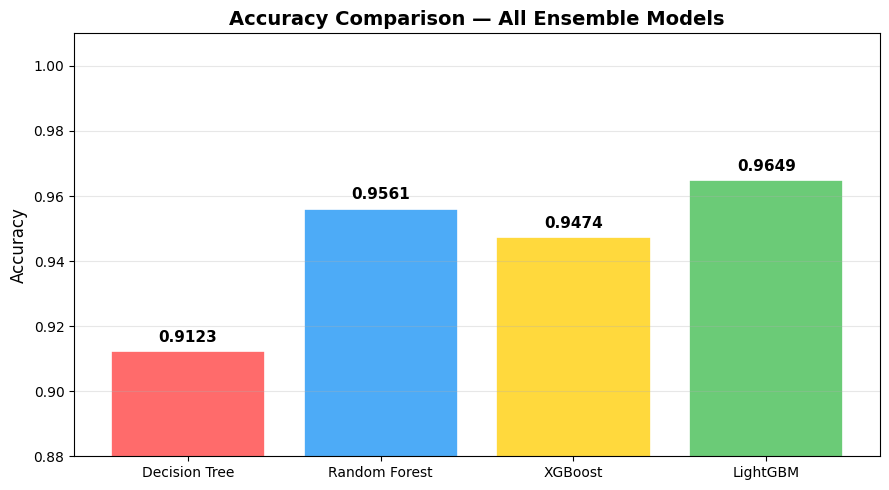

In [8]:
colors = ['#ff6b6b', '#4dabf7', '#ffd93d', '#6bcb77']

plt.figure(figsize=(9, 5))
bars = plt.bar(df.index, df['Accuracy'], color=colors, edgecolor='white', linewidth=1.2)
plt.ylim(0.88, 1.01)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy Comparison — All Ensemble Models', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.002, f'{val:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 📊 Step 6 — Multi-Metric Comparison

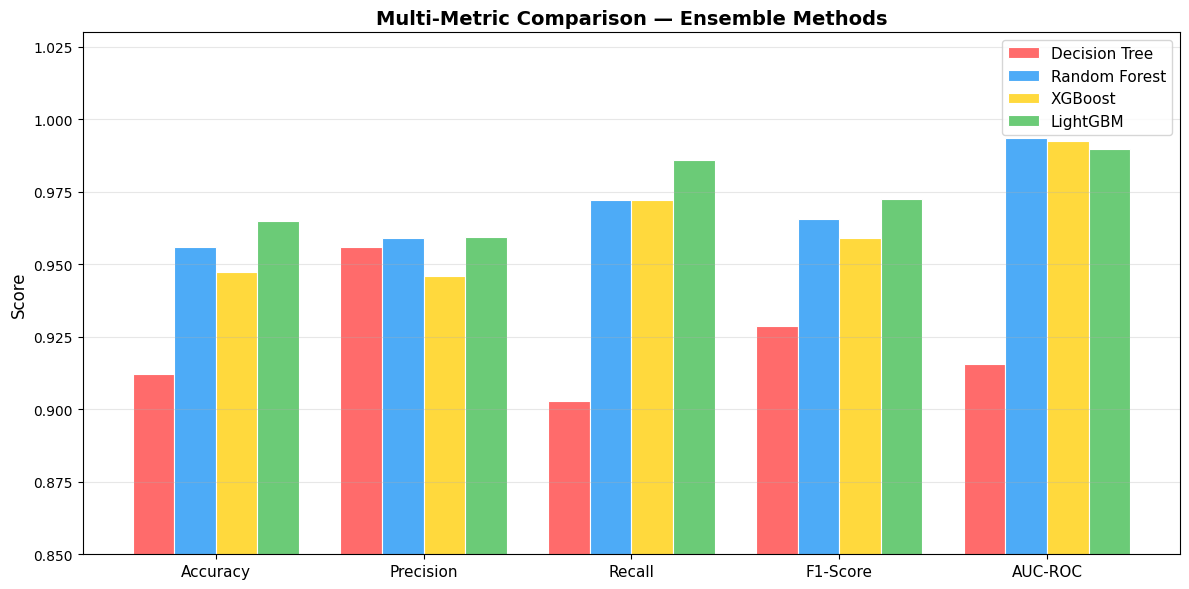

In [9]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x       = np.arange(len(metrics))
width   = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, color) in enumerate(zip(df.index, colors)):
    vals = [df.loc[name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color,
                  edgecolor='white', linewidth=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.85, 1.03)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Multi-Metric Comparison — Ensemble Methods', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📈 Step 7 — ROC Curves (All Models)

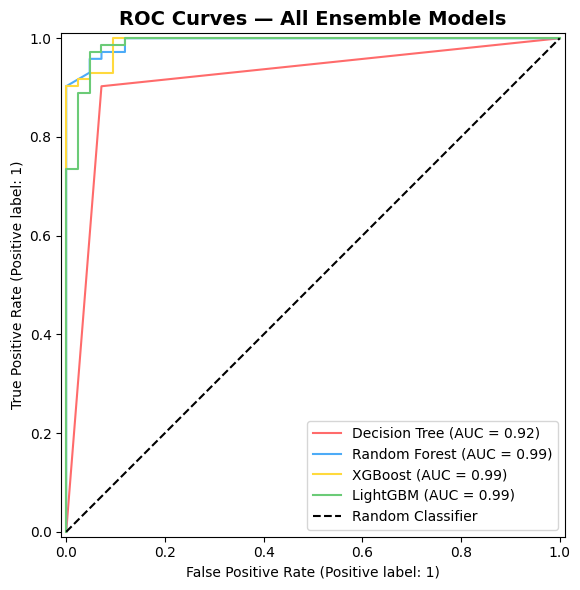

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(models.items(), colors):
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        ax=ax, name=name, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curves — All Ensemble Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

---
## 📉 Step 8 — Confusion Matrices (All Models)

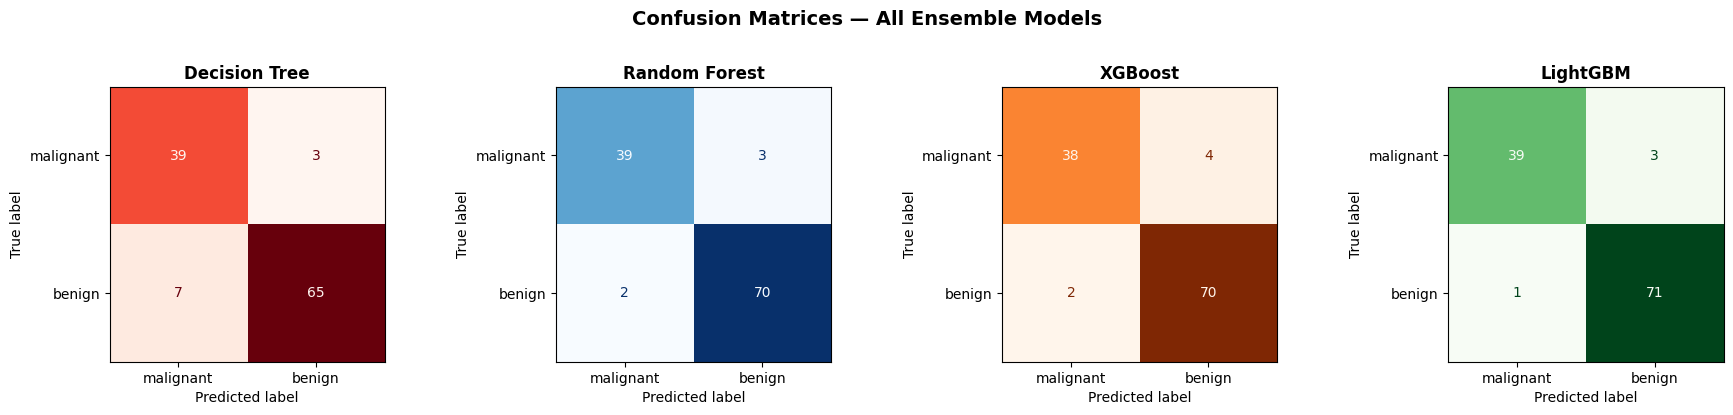

In [11]:
cmaps = ['Reds', 'Blues', 'Oranges', 'Greens']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, model), cmap in zip(axes, models.items(), cmaps):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=data.target_names,
        cmap=cmap, ax=ax, colorbar=False
    )
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Ensemble Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🔁 Step 9 — Cross-Validation Scores

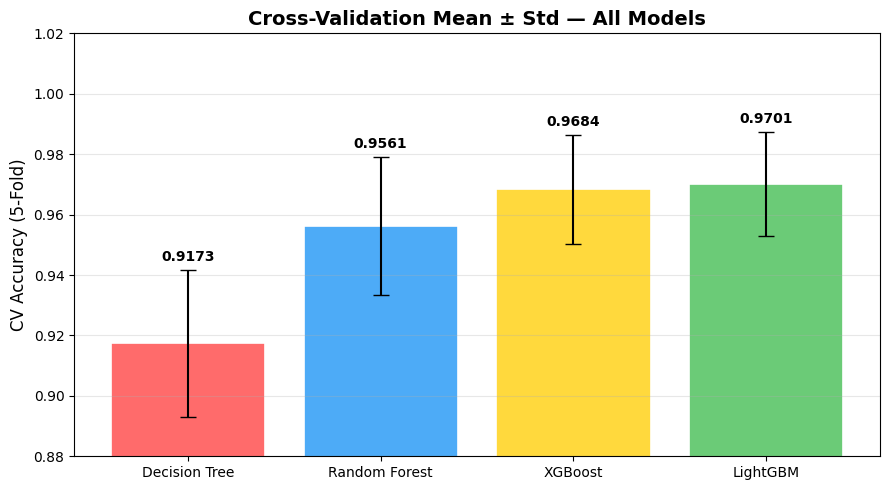

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(df.index, df['CV Mean'], color=colors,
       edgecolor='white', linewidth=1.2,
       yerr=df['CV Std'], capsize=6)

ax.set_ylim(0.88, 1.02)
ax.set_ylabel('CV Accuracy (5-Fold)', fontsize=12)
ax.set_title('Cross-Validation Mean ± Std — All Models', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, (mean, std) in enumerate(zip(df['CV Mean'], df['CV Std'])):
    ax.text(i, mean + std + 0.003, f'{mean:.4f}',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
## ⏱️ Step 10 — Training Speed Comparison

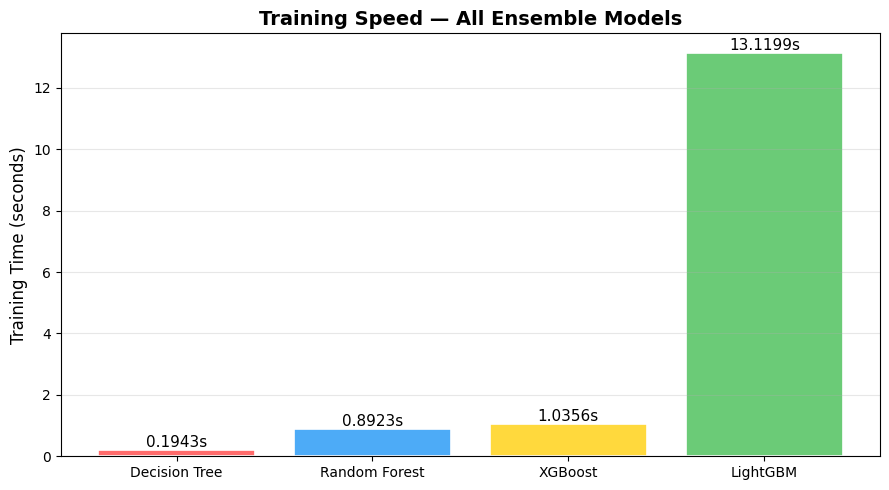

In [13]:
plt.figure(figsize=(9, 5))
bars = plt.bar(df.index, df['Train Time'], color=colors,
               edgecolor='white', linewidth=1.2)
plt.ylabel('Training Time (seconds)', fontsize=12)
plt.title('Training Speed — All Ensemble Models', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, df['Train Time']):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.001, f'{val:.4f}s',
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

---
## 🌡️ Step 11 — Heatmap of All Metrics

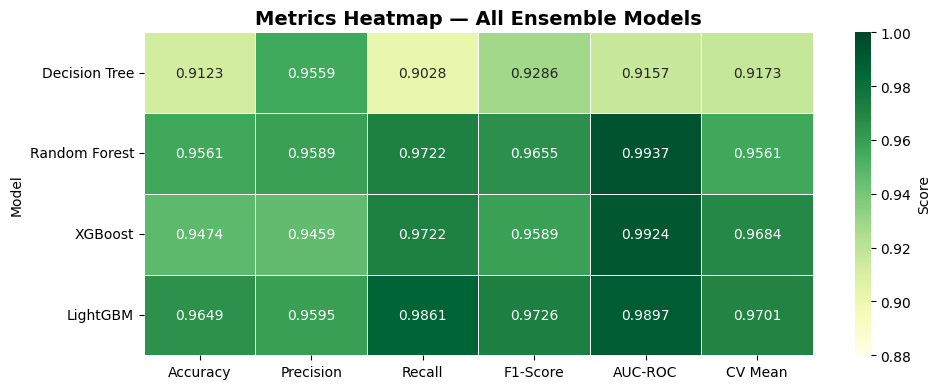

In [15]:
heat_df = df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'CV Mean']].astype(float)

plt.figure(figsize=(10, 4))
sns.heatmap(
    heat_df,
    annot=True, fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    vmin=0.88, vmax=1.00,
    cbar_kws={'label': 'Score'}
)
plt.title('Metrics Heatmap — All Ensemble Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()